In [1]:
import numpy as np
import xarray as xr
from datetime import datetime
import pandas as pd

from som_utils import read_and_transform, build_scaler, train_som

import warnings
warnings.filterwarnings('ignore')

/home/z2034747/.local/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
prefs = {'filename': "/home/scratch/dwefer/GEFSv12/z500_pwat_cape.nc", 
         'vars': ['gh','pwat','cape'], 'wlon': 220, 'elon': 305, 'nlat': 55, 'slat': 20, 
         'som_config': {'x': 5, 'y': 6,'sigma': 1.5, 'random_seed': 42},
         'som_train': {'num_iteration': 10000, 'random_order': True, 'verbose': True}}

trained_som, trained_scaler, train_info, xr_data = train_som(prefs)


current model configuration
{'input_len': 36423, 'random_seed': 42, 'sigma': 1.5, 'x': 5, 'y': 6}
current training configuration
{'data': array([[-0.66050106, -0.68316907, -0.70958024, ..., -0.35766476,
        -0.39876992, -0.47084543],
       [-0.71175027, -0.7709796 , -0.83132076, ..., -0.07086021,
        -0.05198546, -0.06028149],
       [-0.28915408, -0.28948432, -0.29526958, ..., -0.18498929,
        -0.50052845, -0.7557738 ],
       ...,
       [-0.87913156, -0.8735199 , -0.8690234 , ..., -0.03654437,
        -0.12210999, -0.2225972 ],
       [-0.31367952, -0.29052007, -0.26362565, ..., -0.05541589,
        -0.15135957, -0.25826085],
       [-0.43595633, -0.43200427, -0.43102336, ..., -0.12745726,
        -0.18120788, -0.25345182]], dtype=float32),
 'num_iteration': 10000,
 'random_order': True,
 'verbose': True}
 [ 10000 / 10000 ] 100% - 0:00:00 left 
 quantization error: 120.0161869726036


In [104]:
#dims: x,y, node(0,0)
# lat/lon/pper/pper_stats

In [3]:
som_data = train_info["som_train"]["data"]

nx = prefs["som_config"]["x"]
ny = prefs["som_config"]["y"]
n_nodes = nx * ny

v1, v2, v3 = prefs["vars"] 

spatial_dims = {"latitude", "longitude"}
sample_dims = [d for d in xr_data[v1].dims if d not in spatial_dims]

if len(sample_dims) != 1:
    raise ValueError(
        f"Expected exactly one non-spatial/sample dimension, got {xr_data[v1].dims}"
    )

sample_dim = sample_dims[0]

z500_all = xr_data[v1].transpose(sample_dim, "latitude", "longitude").to_numpy()
pwat_all = xr_data[v2].transpose(sample_dim, "latitude", "longitude").to_numpy()
cape_all = xr_data[v3].transpose(sample_dim, "latitude", "longitude").to_numpy()

lat = xr_data["latitude"].values
lon = xr_data["longitude"].values
n_samples, nlat, nlon = z500_all.shape

lon_plot = ((lon + 180) % 360) - 180
lon_order = np.argsort(lon_plot)
lon_plot = lon_plot[lon_order]

z500_all = z500_all[:, :, lon_order]
pwat_all = pwat_all[:, :, lon_order]
cape_all = cape_all[:, :, lon_order]

winmap = trained_som.win_map(som_data, return_indices=True)

freq_dict = {node: len(idxs) for node, idxs in winmap.items()}

nodes = [(i, j) for i in range(nx) for j in range(ny)]
node_to_idx = {node: idx for idx, node in enumerate(nodes)}

z500_avg_data = np.full((n_nodes, nlat, nlon), np.nan, dtype=np.float32)
pwat_avg_data = np.full((n_nodes, nlat, nlon), np.nan, dtype=np.float32)
cape_avg_data = np.full((n_nodes, nlat, nlon), np.nan, dtype=np.float32)

for node in nodes:
    node_idx = node_to_idx[node]
    member_idx = winmap.get(node, [])

    if len(member_idx) == 0:
        continue

    member_idx = np.asarray(member_idx, dtype=int)

    z500_avg_data[node_idx] = np.nanmean(z500_all[member_idx], axis=0)
    pwat_avg_data[node_idx] = np.nanmean(pwat_all[member_idx], axis=0)
    cape_avg_data[node_idx] = np.nanmean(cape_all[member_idx], axis=0)

da_z500 = xr.DataArray(
    z500_avg_data,
    dims=("node", "latitude", "longitude"),
    coords={"node": np.arange(n_nodes), "latitude": lat, "longitude": lon_plot},
    name=v1
)

da_pwat = xr.DataArray(
    pwat_avg_data,
    dims=("node", "latitude", "longitude"),
    coords={"node": np.arange(n_nodes), "latitude": lat, "longitude": lon_plot},
    name=v2
)

da_cape = xr.DataArray(
    cape_avg_data,
    dims=("node", "latitude", "longitude"),
    coords={"node": np.arange(n_nodes), "latitude": lat, "longitude": lon_plot},
    name=v3
)

In [107]:
winmap

defaultdict(list,
            {(4, 4): [0,
              1,
              45,
              47,
              50,
              51,
              53,
              105,
              106,
              107,
              314,
              348,
              403,
              405,
              406,
              407,
              408,
              409,
              416,
              421,
              459,
              462,
              463,
              464,
              694,
              699,
              700,
              701,
              702,
              703,
              704,
              710,
              714,
              752,
              753,
              757,
              758,
              759,
              760,
              761,
              762,
              796,
              797,
              802,
              803,
              804,
              805,
              806,
              807,
              848,
              1082,
             

In [108]:
ds_hail = xr.open_dataset('/home/z2034747/Research/Datasets/P_Per/pper_hail_1979_2023.nc')

In [109]:
winmap_keys = sorted(winmap.keys())

In [110]:
winmap_keys

[(0, 0),
 (0, 1),
 (0, 2),
 (0, 3),
 (0, 4),
 (0, 5),
 (1, 0),
 (1, 1),
 (1, 2),
 (1, 3),
 (1, 4),
 (1, 5),
 (2, 0),
 (2, 1),
 (2, 2),
 (2, 3),
 (2, 4),
 (2, 5),
 (3, 0),
 (3, 1),
 (3, 2),
 (3, 3),
 (3, 4),
 (3, 5),
 (4, 0),
 (4, 1),
 (4, 2),
 (4, 3),
 (4, 4),
 (4, 5)]

In [111]:
ds_sel = ds_hail.isel(time= winmap[winmap_keys[0]])

In [112]:
ds_sel

<xarray.Dataset> Size: 10MB
Dimensions:         (time: 215, x: 93, y: 65)
Coordinates:
  * time            (time) datetime64[ns] 2kB 1979-07-18T12:00:00 ... 1998-09...
  * x               (x) float64 744B 0.0 1.0 2.0 3.0 4.0 ... 89.0 90.0 91.0 92.0
  * y               (y) float64 520B 0.0 1.0 2.0 3.0 4.0 ... 61.0 62.0 63.0 64.0
Data variables:
    lat             (y, x) float64 48kB ...
    lon             (y, x) float64 48kB ...
    p_perfect_hail  (time, y, x) float64 10MB ...
Attributes:
    title:         Practically Perfect Hail Hindcasts
    grid:          80-km NCEP 211
    sigma:         1.5
    author:        Dr. Victor Gensini
    author_email:  vgensini@niu.edu
    citation:      https://doi.org/10.1175/BAMS-D-19-0321.1

In [113]:
winmap_keys[0]

from tqdm import tqdm

In [114]:
pph_data = []

for key in tqdm(winmap_keys):
    nodesel = xr_data.isel(time= winmap[key])
    time_sel = (nodesel.time - np.timedelta64(1, 'D')).astype('datetime64[D]').astype(str)
    
    ds_hail_sel = ds_hail.sel(time= time_sel.values, method= 'nearest')
    
    pph_data.append(ds_hail_sel['p_perfect_hail'])
    
    # print(f'appended node {key}')
    
# for i, key in winmap_keys:
    
    
#     nodesel = xr_data.isel(time=key)

#     # shift back a day bc pper is 12z–12z, and dataset is 0z
#     time_sel = (nodesel.time - np.timedelta64(1, "D")).astype("datetime64[D]").astype(str)

#     ds_hail_sel = ds_hail.sel(time=time_sel, method="nearest")

100%|██████████| 30/30 [00:01<00:00, 18.80it/s]


In [115]:
som_dict = dict(zip(winmap_keys, pph_data))

In [130]:
dataset_list = []

for (som_x, som_y), da in som_dict.items():
    # 1. Convert the DataArray to a Dataset. 
    # You must assign a variable name to the data (e.g., 'geopotential_height')
    ds = da.to_dataset(name="p_perfect_hail")
    
    # 2. Assign the SOM node as coordinates along the existing 'time' dimension
    ds = ds.assign_coords(
        som_x=("time", [som_x] * ds.sizes["time"]),
        som_y=("time", [som_y] * ds.sizes["time"])
    )
    dataset_list.append(ds)

# 3. Concatenate back along the time dimension and sort chronologically
# This results in a dense Dataset with dimensions (time, x, y)
# and your nodes safely stored as coordinates you can filter by later.
final_ds = xr.concat(dataset_list, dim="time").sortby("time")

final_ds = final_ds.assign_coords(lat = ds_hail.lat, lon= ds_hail.lon)

In [168]:
# final_ds.to_netcdf('/home/scratch/peldridge/pper_hail_by_node.nc')

# Test to ensure nodes were stored properly:

In [205]:
som_x = range(0, 5)
som_y = range(0, 6)

truth = []
for i in som_x:
    for j in som_y:
        truth_index= (i * j) + j
        truth.append((som_dict[(i, j)].values == final_ds.where((final_ds.som_x == i) & (final_ds.som_y == j), drop= True)["p_perfect_hail"].values).all())
        print(f'som_dict and dataset match? Node ({i}, {j}): {truth[truth_index]}')
        
print(f'All nodes match? {all(truth)}')

som_dict and dataset match? Node (0, 0): True
som_dict and dataset match? Node (0, 1): True
som_dict and dataset match? Node (0, 2): True
som_dict and dataset match? Node (0, 3): True
som_dict and dataset match? Node (0, 4): True
som_dict and dataset match? Node (0, 5): True
som_dict and dataset match? Node (1, 0): True
som_dict and dataset match? Node (1, 1): True
som_dict and dataset match? Node (1, 2): True
som_dict and dataset match? Node (1, 3): True
som_dict and dataset match? Node (1, 4): True
som_dict and dataset match? Node (1, 5): True
som_dict and dataset match? Node (2, 0): True
som_dict and dataset match? Node (2, 1): True
som_dict and dataset match? Node (2, 2): True
som_dict and dataset match? Node (2, 3): True
som_dict and dataset match? Node (2, 4): True
som_dict and dataset match? Node (2, 5): True
som_dict and dataset match? Node (3, 0): True
som_dict and dataset match? Node (3, 1): True
som_dict and dataset match? Node (3, 2): True
som_dict and dataset match? Node (

# Quick plotting example

In [169]:
# Select Node - in this case, we are using node (0, 0):

ds_sel = final_ds['p_perfect_hail'].where((final_ds.som_x == 0) & (final_ds.som_y == 0), drop= True)

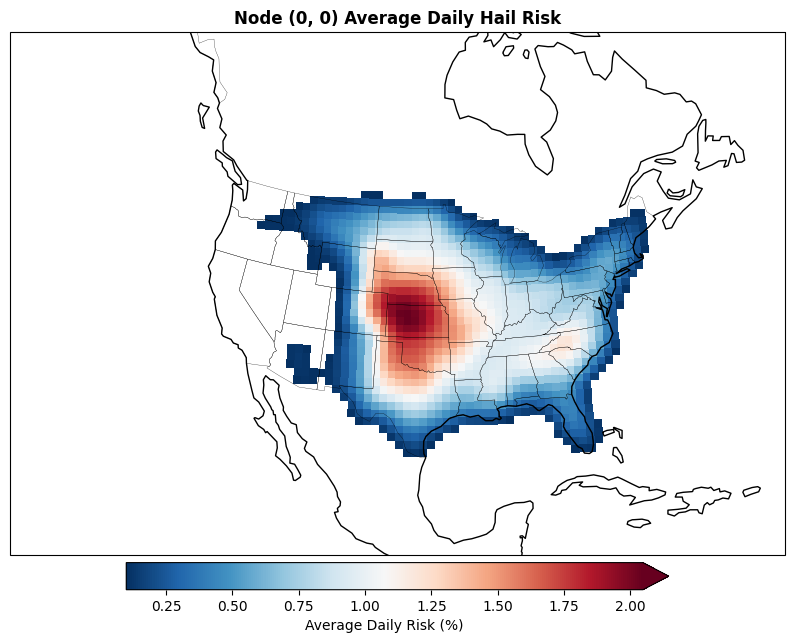

In [166]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.gridspec as GridSpec

plt.figure(figsize= (10, 10))
ax = plt.subplot(1, 1, 1, projection= ccrs.LambertConformal())
data = final_ds['p_perfect_hail'].mean(dim= 'time')

mesh = data.where(data > 0.1).plot.pcolormesh(ax= ax, x= 'lon', y= 'lat', cmap= 'RdBu_r', cbar_kwargs= {'orientation': 'horizontal', 'shrink': 0.7, 'pad': 0.01, 'extend': 'max', 'label': 'Average Daily Risk (%)'}, transform= ccrs.PlateCarree())

ax.coastlines()
ax.add_feature(cfeature.STATES, linewidths= 0.2)

ax.set_title('Node (0, 0) Average Daily Hail Risk', weight= 'bold')

plt.show()

# GEFS dates JSON:

In [11]:
# Index from GEFS: 

import pickle


with open('GEFS_index.pkl', 'wb') as file: 
    pickle.dump(winmap, file)

In [40]:
nice_xr_data = xr_data.time.dt.strftime('%Y-%m-%d %H:%M').values # times in UTC

winmap_dates = {}

for node, idxs in winmap.items():
    dates = []
    
    for idx in idxs:
        date_str = nice_xr_data[idx]
        dates.append(date_str)
        
    winmap_dates[node] = dates

In [42]:
with open('GEFS_dates.pkl', 'wb') as file:
    pickle.dump(winmap_dates, file)